### Import Modules

In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
import numpy as np

In [2]:
pattern = re.compile(
    r'\[GPU (?P<gpu_id>None|\d+)\] Task=(?P<task>[\w_]+)\s+\| '
    r'Batch=(?P<batch>\d+)\s+UBatch=(?P<ubatch>\d+)\s+\| '
    r'Partition=(?P<partition>-?\d+)\s+Target=(?P<target>\w+)\s+\| '
    r'StartTime=(?P<start_time>[0-9.]+)\s+\| '
    r'Time=(?P<time>[0-9.]+) ms\s+\| '
    r'Mem=(?P<mem>[0-9.]+) MB\s+\| '
    r'MaxMem=(?P<max_mem>[0-9.]+) MB\s+\| '
    r'GpuUtil=(?P<gpu_util>\d+)%\s+\| '
    r'Power=(?P<power>[0-9.]+)/(?P<power_limit>[0-9.]+)W'
)
def assign_color(row):
    task = row['task'].lower()
    is_teacher = row['target'] is True
    is_student = row['target'] is False

    # Teacher forward
    if is_teacher:
        if 'compute_forward' in task:
            return '#01b112'  # 진한 초록
        elif 'copy_model' in task:
            return '#74cb15'  # 밝은 청록
        elif 'copy_batch' in task:
            return '#b8e428'  # 연한 초록
        elif 'copy_batch_out' in task:
            return '#f9fc45'  # 아주 연한 녹색

    # Student forward
    if is_student:
        if 'compute_forward' in task:
            return '#0265ac'  # 진한 파랑
        elif 'copy_model' in task:
            return '#008ab5'  # 연한 청록
        elif 'copy_batch' in task:
            return '#00acb7'  # 중간 파랑
        elif 'copy_batch_out' in task:
            return '#00d2a6'  # 연한 파랑

    # Student backward
    if is_student:
        if 'compute_backward' in task:
            return '#cf5702'  # 진한 오렌지
        elif 'compute_loss' in task:
            return '#ee8925'  # 덜진한 오렌지
        elif 'copy_grad' in task:
            return '#e99b1e'  # 중간 오렌지
        elif 'copy_grad_out' in task:
            return '#dbbd24'  # 밝은 오렌지

    # Optimization
    if 'compute_optimize' in task:
        return '#d62728'  # 빨강

    # Feed / terminate
    if 'feed_batch' in task or 'terminate' in task:
        return '#7f7f7f'  # 회색

    # Default fallback
    return '#bdbdbd'  # 흐린 회색

import matplotlib.patches as mpatches

legend_elements = [
    # Teacher Forward 관련
    mpatches.Patch(facecolor='#01b112', label='Teacher Compute Forward'),     # 진한 초록
    mpatches.Patch(facecolor='#74cb15', label='Teacher Copy Model'),          # 중간 초록
    mpatches.Patch(facecolor='#b8e428', label='Teacher Copy Batch'),          # 연한 초록
    mpatches.Patch(facecolor='#f9fc45', label='Teacher Copy Batch Out'),      # 아주 연한 초록

    # Student Forward 관련
    mpatches.Patch(facecolor='#0265ac', label='Student Compute Forward'),     # 진한 파랑
    mpatches.Patch(facecolor='#008ab5', label='Student Copy Model'),          # 중간 파랑
    mpatches.Patch(facecolor='#00acb7', label='Student Copy Batch'),          # 연한 파랑
    mpatches.Patch(facecolor='#00d2a6', label='Student Copy Batch Out'),      # 아주 연한 파랑

    # Student Backward 관련
    mpatches.Patch(facecolor='#cf5702', label='Student Compute Backward'),    # 진한 오렌지
    mpatches.Patch(facecolor='#de7e0e', label='Compute Loss'),                # 중간 오렌지
    mpatches.Patch(facecolor='#e99b1e', label='Copy Grad'),                   # 밝은 오렌지
    mpatches.Patch(facecolor='#dbbd24', label='Copy Grad Out'),              # 아주 밝은 오렌지

    # 기타
    mpatches.Patch(facecolor='#d62728', label='Optimization'),               # 빨강
    mpatches.Patch(facecolor='#7f7f7f', label='Feed/Terminate'),             # 회색
]

kd_task_order = [
    "feed_batch",
    "copy_model",
    "copy_batch",
    "compute_forward",
    "copy_batch_out",
    "compute_loss",
    "compute_backward",
    "copy_grad_out",
    "copy_grad",
    "compute_optimize",
    "terminate"
]


### Set Dataset 

In [ ]:
DATASET_NAME = 'i100' # i100 (ImageNet100) or c10 (CIFAR-10)
BATCH_SIZE = 128

## 1. Even Partitioning

In [17]:
MODIFY_TYPE = '_even_split' # '_even_split' or ''

In [18]:
LOG_FILE = 'gpu_task_summary_i100_batch6_10_b128.txt'

even_split_records = []

with open(LOG_FILE, 'r') as f:
    for line in f:
        match = pattern.search(line.strip())
        if not match:
            continue

        data = match.groupdict()
        even_split_records.append({
            'gpu_id': int(data['gpu_id']) if data['gpu_id'] != 'None' else -1,
            'task': data['task'],
            'batch': int(data['batch']),
            'ubatch': int(data['ubatch']),
            'partition': int(data['partition']),
            'target': data['target'] == 'True',
            'start_time': float(data['start_time']),
            'time': float(data['time']),
            'mem': float(data['mem']),
            'max_mem': float(data['max_mem']),
            'power': float(data['power']),
        })

even_df = pd.DataFrame(even_split_records)
print(even_df.head())


   gpu_id             task  batch  ubatch  partition  target    start_time  \
0       0       copy_batch      1       0          0    True  1.774246e+09   
1       0  compute_forward      1       0          0    True  1.774246e+09   
2       0       copy_batch      1       0          0   False  1.774246e+09   
3       0        copy_grad      1       0          0   False  1.774246e+09   
4       0  compute_forward      1       0          0   False  1.774246e+09   

      time     mem  max_mem   power  
0     3.12  349.43   350.19  294.41  
1   425.11  358.32   366.88  268.43  
2     0.17  350.77   350.77  294.41  
3  3737.89  430.92   431.69  222.95  
4   147.37  431.69   431.69  241.12  


(1) Batch 6-10

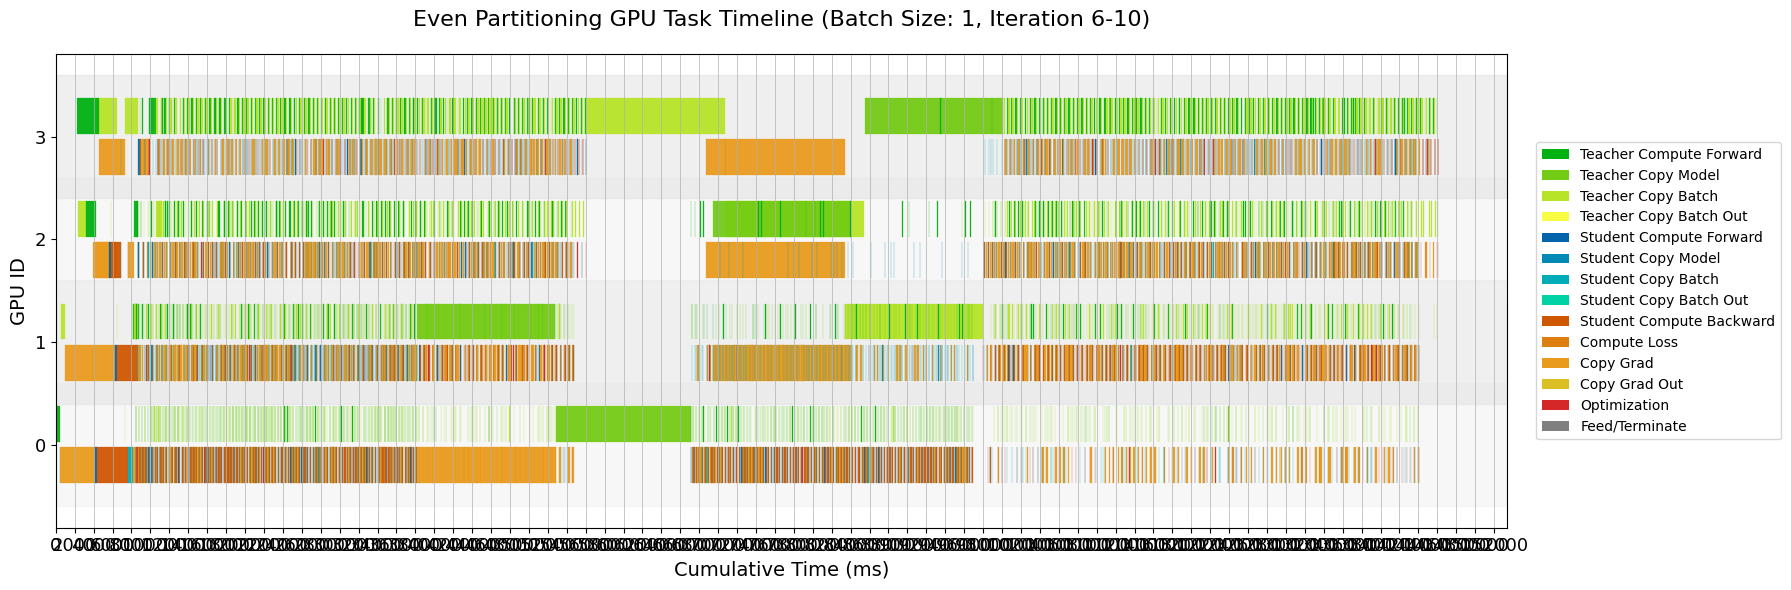

In [19]:
#even_df['start_time'] = even_df['time'].cumsum().shift(fill_value=0)
even_df['start_time'] = even_df.groupby('gpu_id')['time'].cumsum().shift(fill_value=0)
even_df['end_time'] = even_df['start_time'] + even_df['time']

# teacher와 student를 시각적으로 분리 (겹치지 않도록)
def offset_id(row):
    return row['gpu_id'] + (0.2 if row['target'] else -0.2)

even_df['color'] = even_df.apply(assign_color, axis=1)
even_df['y_pos'] = even_df.apply(lambda row: row['gpu_id'] + (0.2 if row['target'] else -0.2), axis=1)

# Gantt-style plot
fig, ax = plt.subplots(figsize=(18, 6))
unique_gpu_ids = sorted(even_df['gpu_id'].unique())
y_margin = 0.6  # margin around center y for colored bands


for i, gpu in enumerate(unique_gpu_ids):
    color = '#f0f0f0' if i % 2 == 0 else '#e0e0e0'
    plt.axhspan(gpu - y_margin, gpu + y_margin, color=color, alpha=0.5, zorder=0)


for _, row in even_df.iterrows():
    plt.barh(
        y=row['y_pos'],
        width=row['time'],
        left=row['start_time'],
        height=0.35,
        color=row['color'],
        edgecolor=row['color'],      # 내부 색상과 동일한 윤곽선
        linewidth=0.2,
        alpha=0.95
    )

plt.xticks(fontsize=13)
plt.yticks(unique_gpu_ids, fontsize=13)
plt.xlabel('Cumulative Time (ms)', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.title(f'Even Partitioning GPU Task Timeline (Batch Size: {BATCH_SIZE}, Iteration 6-10)', fontsize=16, pad=20)
plt.grid(axis='x', linestyle='-', linewidth=0.5)

ax.xaxis.set_major_locator(MultipleLocator(2000))  # 1000ms 단위 눈금선
plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True
)


plt.tight_layout()
plt.show()

(2) Batch 8,9

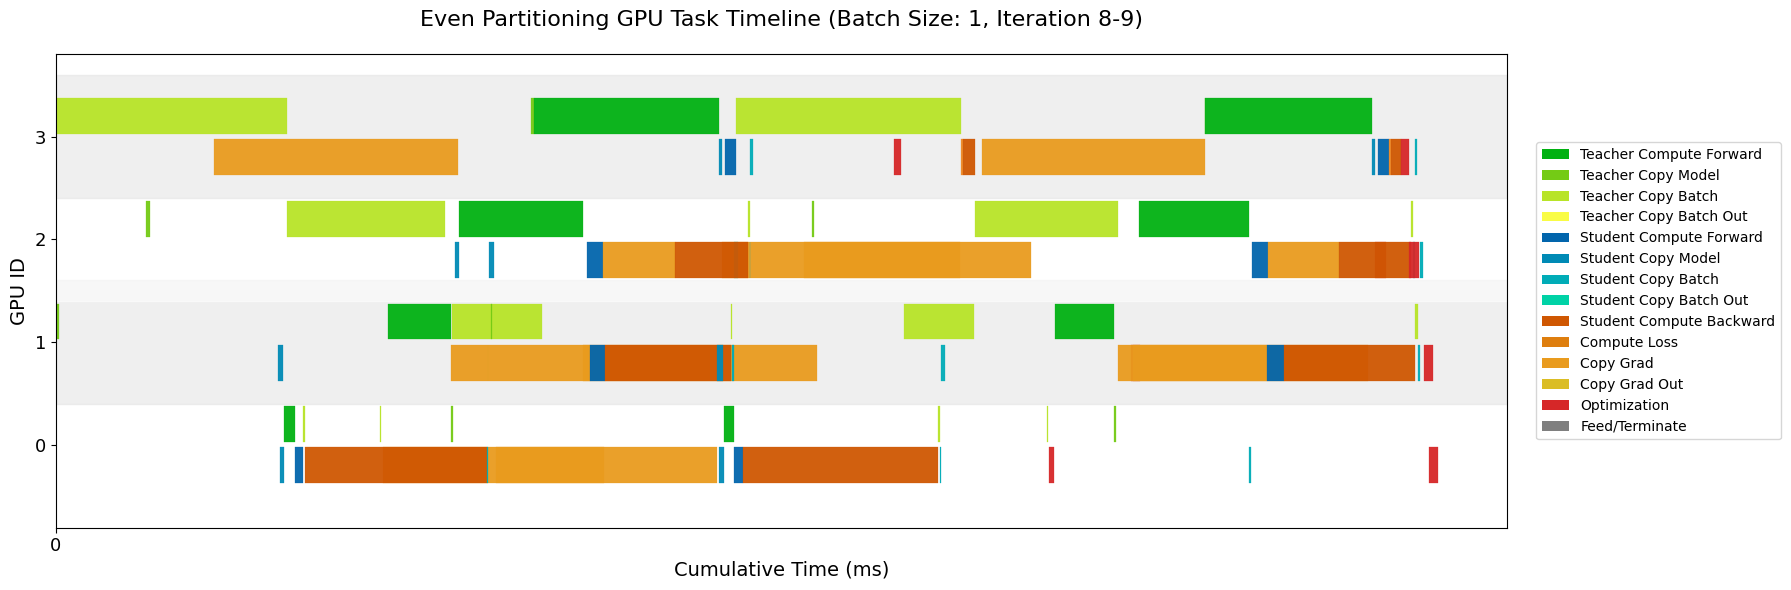

In [20]:
even_df_8_9 = even_df[even_df['batch'].isin([8,9]) & (even_df['gpu_id'] != -1)].reset_index(drop=True)
# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
even_df_8_9.head()

even_df_8_9['color'] = even_df_8_9.apply(assign_color, axis=1)
even_df_8_9['y_pos'] = even_df_8_9.apply(lambda row: row['gpu_id'] + (0.2 if row['target'] else -0.2), axis=1)

# 누적 실행 시간 기반 start_time / end_time
even_df_8_9['start_time'] = even_df_8_9.groupby('gpu_id')['time'].cumsum().shift(fill_value=0)
even_df_8_9['end_time'] = even_df_8_9['start_time'] + even_df_8_9['time']



fig, ax = plt.subplots(figsize=(18, 6))

# GPU 밴드
unique_gpu_ids = sorted(even_df_8_9['gpu_id'].unique())
y_margin = 0.6
for i, gpu in enumerate(unique_gpu_ids):
    color = '#ffffff' if i % 2 == 0 else '#e0e0e0'
    plt.axhspan(gpu - y_margin, gpu + y_margin, color=color, alpha=0.5, zorder=0)

for _, row in even_df_8_9.iterrows():
    plt.barh(
        y=row['y_pos'],
        left=row['start_time'],
        width=row['time'],
        height=0.35,
        color=row['color'],
        edgecolor=row['color'],
        linewidth=0.2,
        alpha=0.95,
        zorder=2
    )

plt.xticks(fontsize=13)
plt.yticks(unique_gpu_ids, fontsize=13)
plt.xlabel('Cumulative Time (ms)', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.title(f'Even Partitioning GPU Task Timeline (Batch Size: {BATCH_SIZE}, Iteration 8-9)', fontsize=16, pad=20)
plt.grid(axis='x', linestyle='-', linewidth=0.5, alpha=0.4)

plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True
)

ax.xaxis.set_major_locator(MultipleLocator(1000))  # 100ms 단위 눈금선
ax.grid(axis='x', linestyle='-', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()


(3) Memory Usage

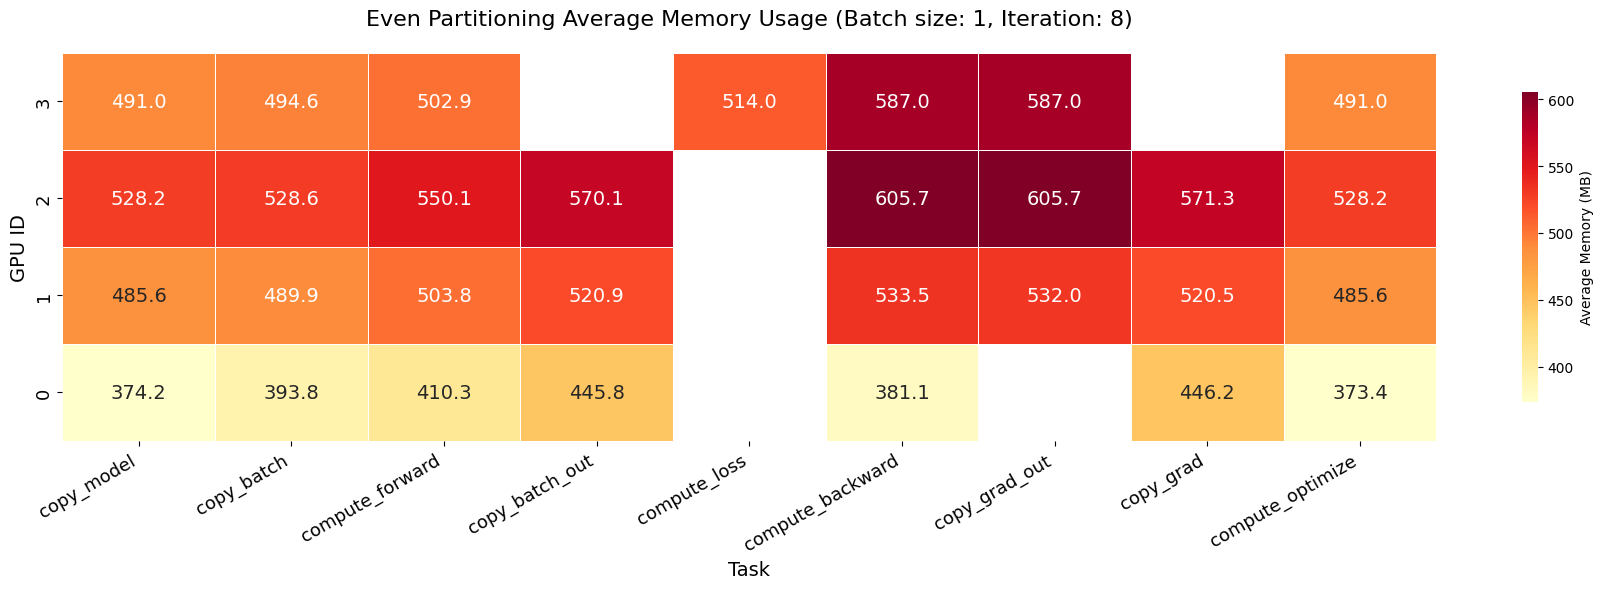

In [21]:
even_df_8 = even_df_8_9[(even_df_8_9['batch'] == 8) & (even_df_8_9['gpu_id'] != -1)].reset_index(drop=True)

heatmap_data = even_df_8.pivot_table(
    index='gpu_id',
    columns='task',
    values='mem',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd',
    linewidths=0.5,
    # vmax=5000,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Memory (MB)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Even Partitioning Average Memory Usage (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.tight_layout()
plt.show()

(4) Latency

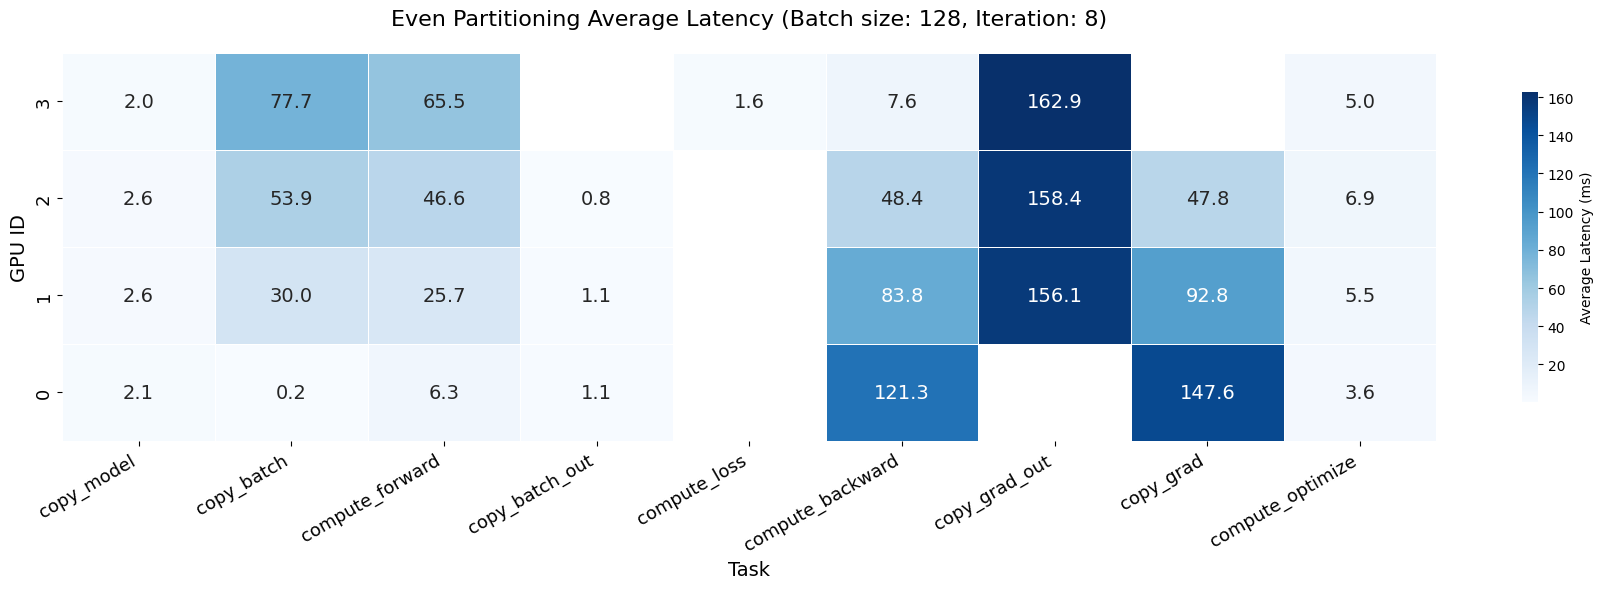

In [9]:
heatmap_data = even_df_8.pivot_table(
    index='gpu_id',
    columns='task',
    values='time',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='Blues',
    linewidths=0.5,
    # vmax=100,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Latency (ms)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Even Partitioning Average Latency (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)

plt.tight_layout()
plt.show()

(5) Power

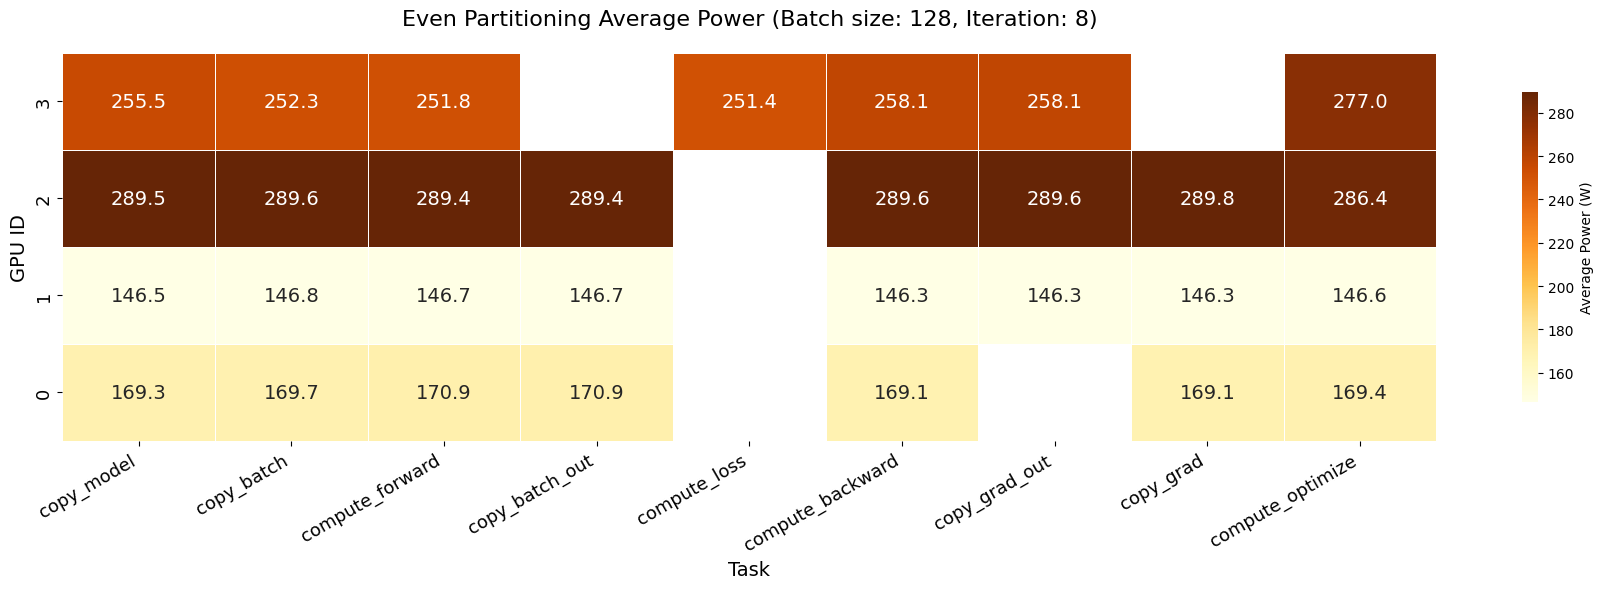

In [28]:
heatmap_data = even_df_8.pivot_table(
    index='gpu_id',
    columns='task',
    values='power',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='YlOrBr',
    linewidths=0.5,
    # vmax=100,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Power (W)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Even Partitioning Average Power (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)

plt.tight_layout()
plt.show()

## 2. Default Partitioning

In [11]:
MODIFY_TYPE = '' # '_even_split' or ''

In [12]:
default_split_log = 'gpu_task_summary_default(vits,effb0).txt'

default_split_records = []

with open(default_split_log, 'r') as f:
    for line in f:
        match = pattern.search(line.strip())
        if not match:
            continue

        data = match.groupdict()
        default_split_records.append({
            'gpu_id': int(data['gpu_id']) if data['gpu_id'] != 'None' else -1,
            'task': data['task'],
            'batch': int(data['batch']),
            'ubatch': int(data['ubatch']),
            'partition': int(data['partition']),
            'target': data['target'] == 'True',
            'start_time': float(data['start_time']),
            'time': float(data['time']),
            'mem': float(data['mem']),
            'max_mem': float(data['max_mem']),
            'power': float(data['power']),
        })

default_df = pd.DataFrame(default_split_records)

print(default_df.head())
print(f"Total records: {len(default_df)}")


   gpu_id             task  batch  ubatch  partition  target    start_time  \
0       1       copy_model      6       0          1    True  1.771643e+09   
1       0       copy_model      6       0          0    True  1.771643e+09   
2       0       copy_batch      6       0          0    True  1.771643e+09   
3       0  compute_forward      6       0          0    True  1.771643e+09   
4       0       copy_batch      6       1          0    True  1.771643e+09   

   time      mem  max_mem   power  
0  0.00    88.37  3502.86  192.34  
1  1.03   119.67  6946.00  206.69  
2  5.82  6797.44  6946.00  206.69  
3  9.09  6809.84  6946.00  223.44  
4  3.28  6834.54  6946.00  206.69  
Total records: 695


(1) Batch6-10

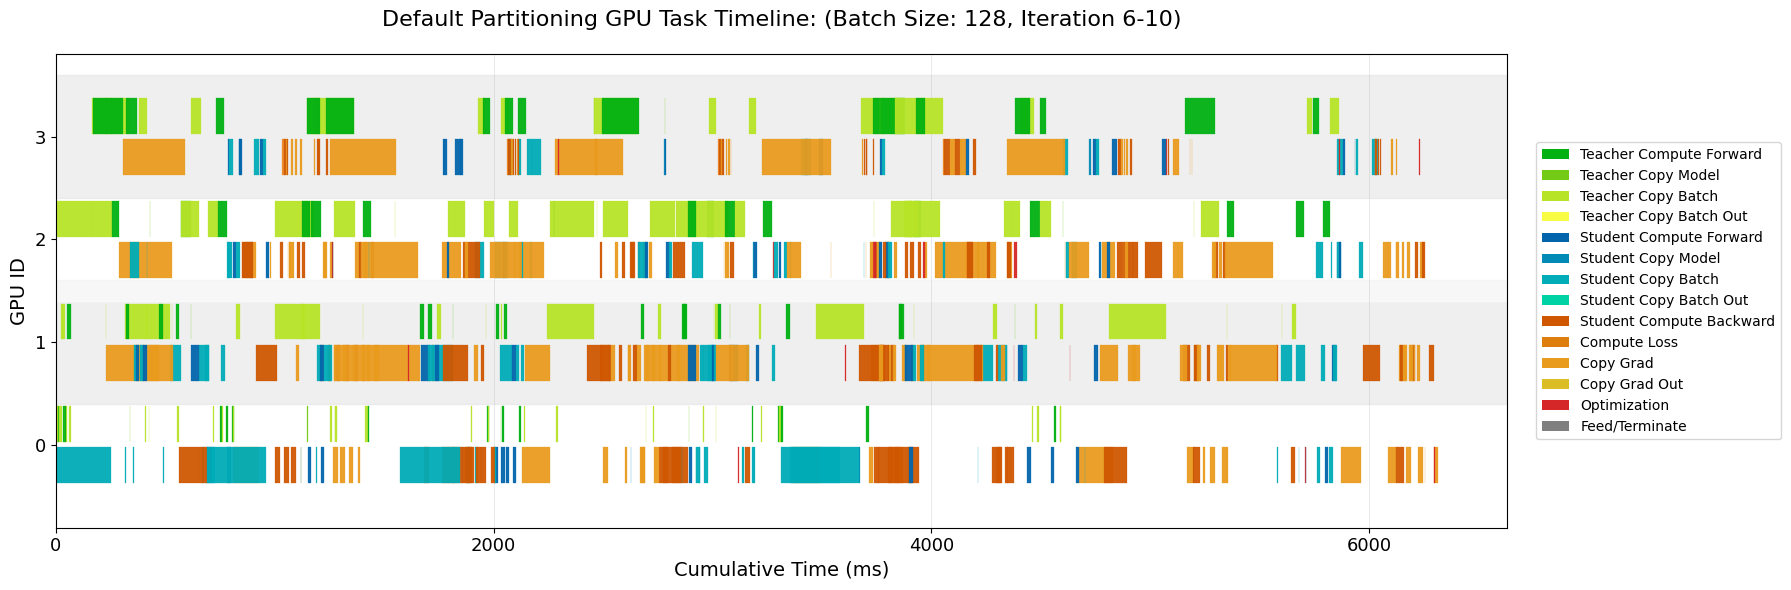

In [13]:
default_df['color'] = default_df.apply(assign_color, axis=1)
default_df['y_pos'] = default_df.apply(lambda row: row['gpu_id'] + (0.2 if row['target'] else -0.2), axis=1)

# 누적 실행 시간 기반 start_time / end_time 생성
default_df['start_time'] = default_df.groupby('gpu_id')['time'].cumsum().shift(fill_value=0)
default_df['end_time'] = default_df['start_time'] + default_df['time']

fig, ax = plt.subplots(figsize=(18, 6))

# GPU 밴드
unique_gpu_ids = sorted(default_df['gpu_id'].unique())
y_margin = 0.6
for i, gpu in enumerate(unique_gpu_ids):
    color = '#ffffff' if i % 2 == 0 else '#e0e0e0'
    plt.axhspan(gpu - y_margin, gpu + y_margin, color=color, alpha=0.5, zorder=0)

for _, row in default_df.iterrows():
    plt.barh(
        y=row['y_pos'],
        left=row['start_time'],
        width=row['time'],
        height=0.35,
        color=row['color'],
        edgecolor=row['color'],
        linewidth=0.2,
        alpha=0.95,
        zorder=2
    )

plt.xticks(fontsize=13)
plt.yticks(unique_gpu_ids, fontsize=13)
plt.xlabel('Cumulative Time (ms)', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.title(f'Default Partitioning GPU Task Timeline: (Batch Size: {BATCH_SIZE}, Iteration 6-10)', fontsize=16, pad=20)
plt.grid(axis='x', linestyle='-', linewidth=0.5, alpha=0.4)

ax.xaxis.set_major_locator(MultipleLocator(2000))  # 100ms 단위 눈금선
plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True
)


plt.tight_layout()
plt.show()


(2) Batch 8, 9

In [15]:
default_df_8_9 = default_df[default_df['batch'].isin([8,9]) & (default_df['gpu_id'] != -1)].reset_index(drop=True)
# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
default_df_8_9

,gpu_id,task,batch,ubatch,partition,target,start_time,time,mem,max_mem,power,color,y_pos,end_time
0,1,copy_model,8,0,1,True,1815.64,1.06,88.37,3502.86,202.19,#74cb15,1.2,1816.70
1,0,copy_model,8,0,0,True,1149.31,1.24,85.67,6946.00,227.66,#74cb15,0.2,1150.55
2,0,copy_batch,8,0,0,True,1897.29,3.57,4845.98,6946.00,229.35,#b8e428,0.2,1900.86
3,0,compute_forward,8,0,0,True,1968.61,10.11,6809.84,6946.00,229.35,#01b112,0.2,1978.72
4,0,copy_batch,8,1,0,True,1253.78,6.50,6834.54,6946.00,229.35,#b8e428,0.2,1260.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,0,compute_backward,9,0,0,False,5641.10,20.97,73.06,6946.00,223.26,#cf5702,-0.2,5662.07
274,1,compute_optimize,9,0,1,False,4633.18,1.31,88.37,3502.86,194.74,#d62728,0.8,4634.49
275,0,compute_optimize,9,0,0,False,5707.98,2.21,72.92,6946.00,223.26,#d62728,-0.2,5710.19
276,2,compute_optimize,9,0,2,False,3962.44,7.45,103.85,1427.30,288.27,#d62728,1.8,3969.89


In [16]:
# default_df_8_9 = default_df[default_df['batch'].isin([8,9]) & (default_df['gpu_id'] != -1)].reset_index(drop=True)
filtered_df_8_9 = default_df_8_9[
    default_df_8_9['task'].isin(['copy_batch', 'copy_batch_out', 'compute_forward']) & (default_df_8_9['partition'] == 3)
    # default_df_8_9['task'].isin(['compute_forward', 'compute_backward', 'compute_optimize']) & (default_df_8_9['target'] == False) & (default_df_8_9['partition'] == 3)
].reset_index(drop=True)
filtered_df_8_9 = filtered_df_8_9.sort_values(by='start_time', ascending=True).reset_index(drop=True)
pd.set_option('display.max_rows', None)
filtered_df_8_9

,gpu_id,task,batch,ubatch,partition,target,start_time,time,mem,max_mem,power,color,y_pos,end_time
0,3,copy_batch,8,1,3,True,2033.51,36.96,139.61,189.47,274.59,#b8e428,3.2,2070.47
1,3,compute_forward,8,1,3,True,2052.05,35.18,60.08,189.47,274.59,#01b112,3.2,2087.23
2,3,compute_forward,8,2,3,True,2112.72,33.55,62.17,189.47,274.59,#01b112,3.2,2146.27
3,3,copy_batch,8,0,3,False,2151.73,22.20,59.55,189.47,272.95,#00acb7,2.8,2173.93
4,3,copy_batch,8,0,3,True,2459.15,200.15,57.93,189.47,274.59,#b8e428,3.2,2659.30
5,3,compute_forward,8,0,3,True,2497.09,165.19,57.94,189.47,274.59,#01b112,3.2,2662.28
6,3,compute_forward,8,0,3,False,2782.86,4.88,80.70,189.47,272.95,#0265ac,2.8,2787.74
7,3,copy_batch,9,2,3,True,2985.73,31.62,62.17,189.47,273.36,#b8e428,3.2,3017.35
8,3,copy_batch,8,2,3,True,3167.21,33.07,62.15,189.47,274.59,#b8e428,3.2,3200.28
9,3,copy_batch,8,1,3,False,3406.60,20.57,68.29,189.47,272.95,#00acb7,2.8,3427.17


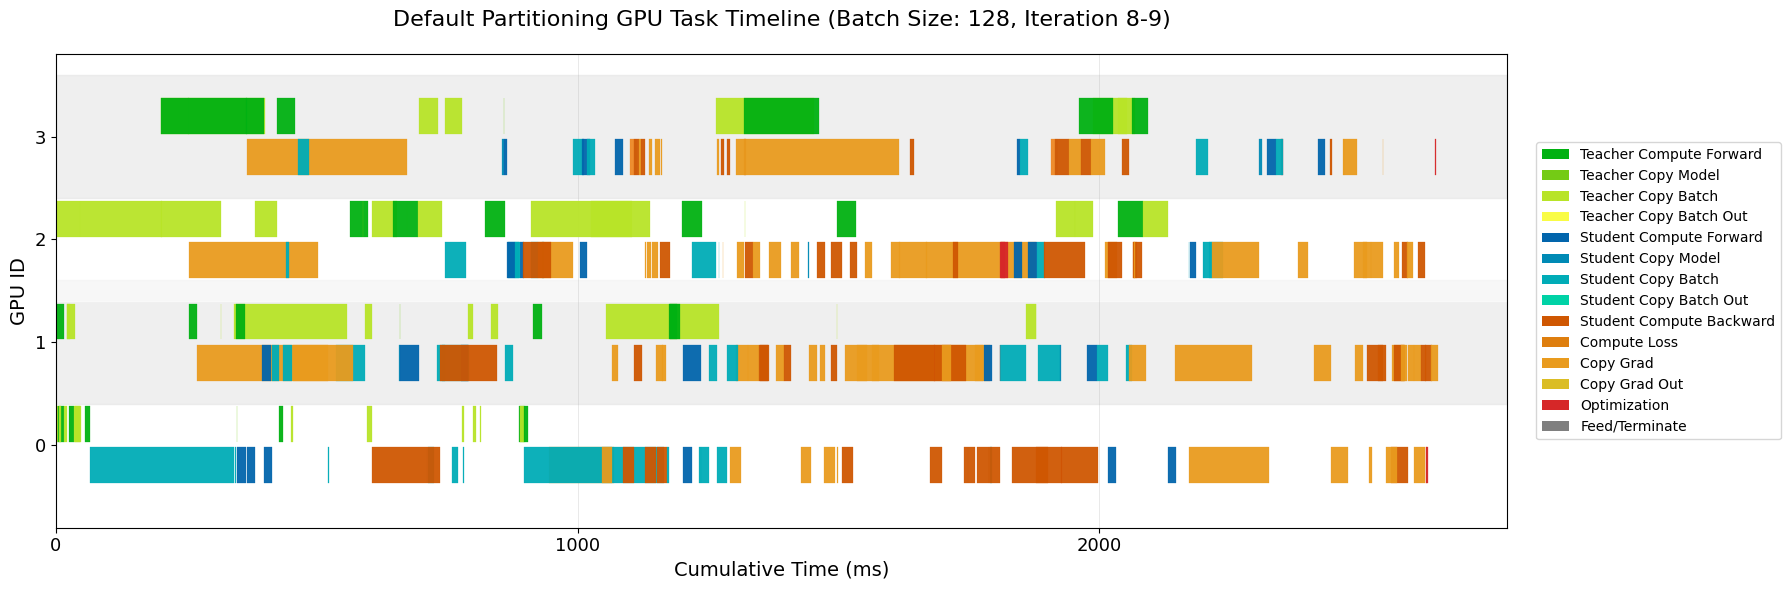

In [17]:
default_df_8_9['color'] = default_df_8_9.apply(assign_color, axis=1)
default_df_8_9['y_pos'] = default_df_8_9.apply(lambda row: row['gpu_id'] + (0.2 if row['target'] else -0.2), axis=1)

# 누적 실행 시간 기반 start_time / end_time
default_df_8_9['start_time'] = default_df_8_9.groupby('gpu_id')['time'].cumsum().shift(fill_value=0)
default_df_8_9['end_time'] = default_df_8_9['start_time'] + default_df_8_9['time']



fig, ax = plt.subplots(figsize=(18, 6))

# GPU 밴드
unique_gpu_ids = sorted(default_df_8_9['gpu_id'].unique())
y_margin = 0.6
for i, gpu in enumerate(unique_gpu_ids):
    color = '#ffffff' if i % 2 == 0 else '#e0e0e0'
    plt.axhspan(gpu - y_margin, gpu + y_margin, color=color, alpha=0.5, zorder=0)

for _, row in default_df_8_9.iterrows():
    plt.barh(
        y=row['y_pos'],
        left=row['start_time'],
        width=row['time'],
        height=0.35,
        color=row['color'],
        edgecolor=row['color'],
        linewidth=0.2,
        alpha=0.95,
        zorder=2
    )

plt.xticks(fontsize=13)
plt.yticks(unique_gpu_ids, fontsize=13)
plt.xlabel('Cumulative Time (ms)', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)
plt.title(f'Default Partitioning GPU Task Timeline (Batch Size: {BATCH_SIZE}, Iteration 8-9)', fontsize=16, pad=20)
plt.grid(axis='x', linestyle='-', linewidth=0.5, alpha=0.4)

plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True
)

ax.xaxis.set_major_locator(MultipleLocator(1000))  # 100ms 단위 눈금선
ax.grid(axis='x', linestyle='-', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()


(3) Memory Usage

   gpu_id             task  batch  ubatch  partition  target  start_time  \
0       1       copy_model      8       0          1    True        0.00   
1       0       copy_model      8       0          0    True        1.06   
2       0       copy_batch      8       0          0    True        1.24   
3       0  compute_forward      8       0          0    True        4.81   
4       0       copy_batch      8       1          0    True       14.92   

    time      mem  max_mem   power    color  y_pos  end_time  
0   1.06    88.37  3502.86  202.19  #74cb15    1.2      1.06  
1   1.24    85.67  6946.00  227.66  #74cb15    0.2      2.30  
2   3.57  4845.98  6946.00  229.35  #b8e428    0.2      4.81  
3  10.11  6809.84  6946.00  229.35  #01b112    0.2     14.92  
4   6.50  6834.54  6946.00  229.35  #b8e428    0.2     21.42  


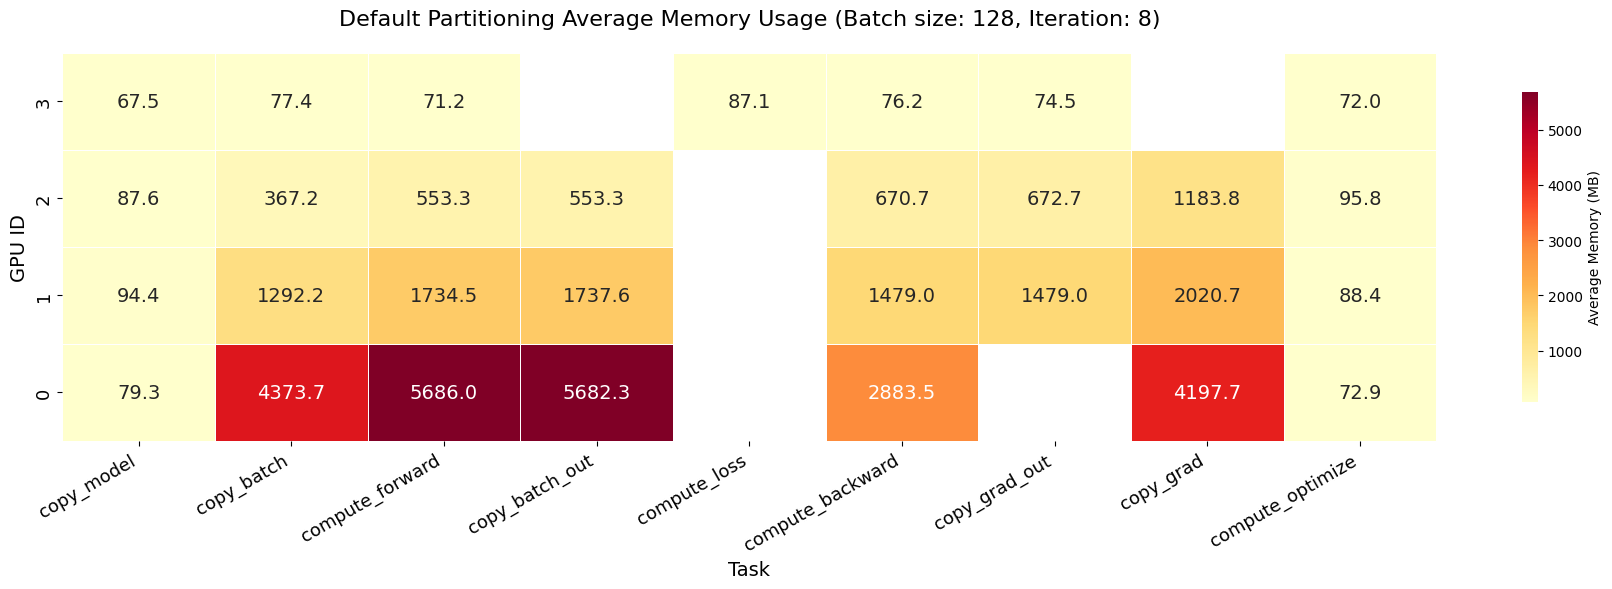

In [18]:
default_df_8 = default_df_8_9[(default_df_8_9['batch'] == 8) & (default_df_8_9['gpu_id'] != -1)].reset_index(drop=True)
print(default_df_8.head())
heatmap_data = default_df_8.pivot_table(
    index='gpu_id',
    columns='task',
    values='mem',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd',
    linewidths=0.5,
    # vmax=2000,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Memory (MB)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Default Partitioning Average Memory Usage (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)

plt.tight_layout()
plt.show()

(4) Latency

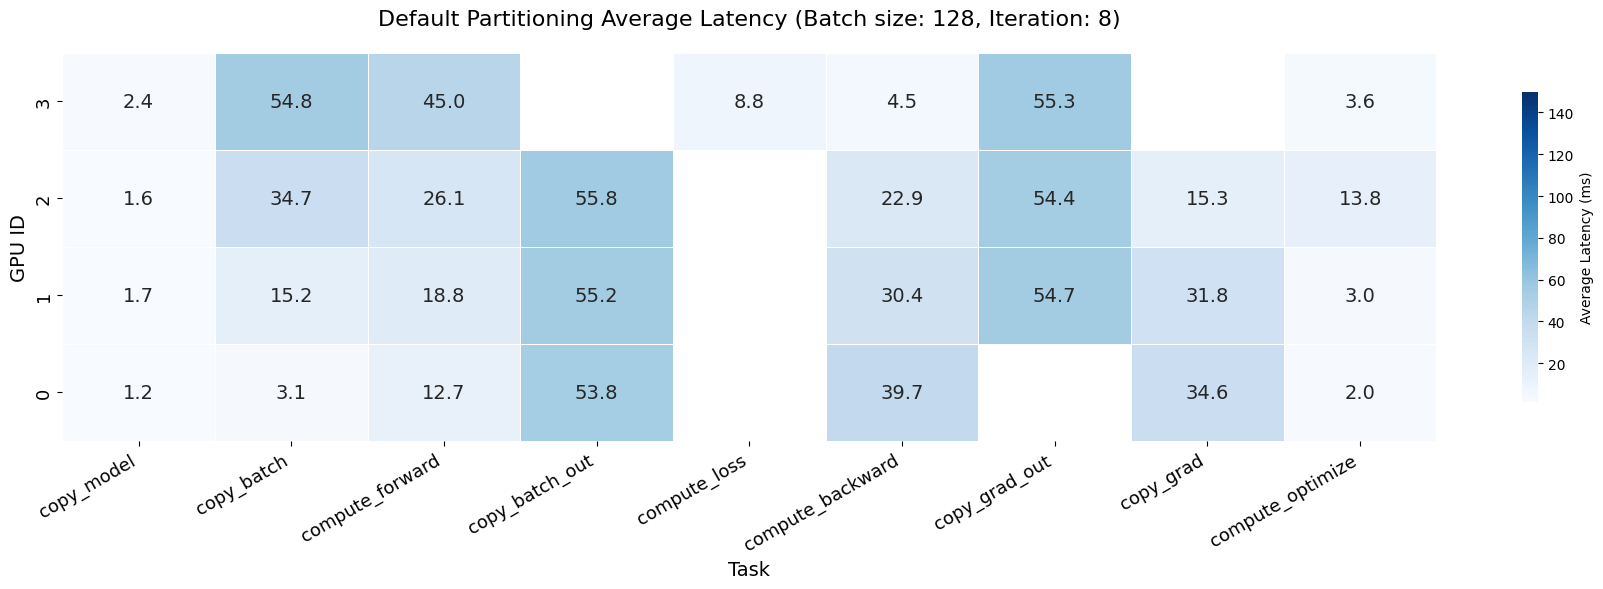

In [19]:
heatmap_data = default_df_8.pivot_table(
    index='gpu_id',
    columns='task',
    values='time',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='Blues',
    linewidths=0.5,
    vmax=150,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Latency (ms)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Default Partitioning Average Latency (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)

plt.tight_layout()
plt.show()

(5) Power

In [48]:
default_df_8.head()

,gpu_id,task,batch,ubatch,partition,target,start_time,time,mem,max_mem,power,color,y_pos,end_time
0,0,copy_model,8,0,0,True,0.00,1.03,373.15,5847.67,74.3,#74cb15,0.2,1.03
1,0,copy_batch,8,0,0,True,1.03,2.55,4307.34,5847.67,74.3,#b8e428,0.2,3.58
2,0,compute_forward,8,0,0,True,3.58,120.97,5399.14,5847.67,74.3,#01b112,0.2,124.55
3,0,copy_batch,8,1,0,True,124.55,2.31,5552.35,5847.67,74.3,#b8e428,0.2,126.86
4,0,copy_batch_out,8,0,0,True,126.86,119.71,5423.26,5847.67,74.3,#b8e428,0.2,246.57


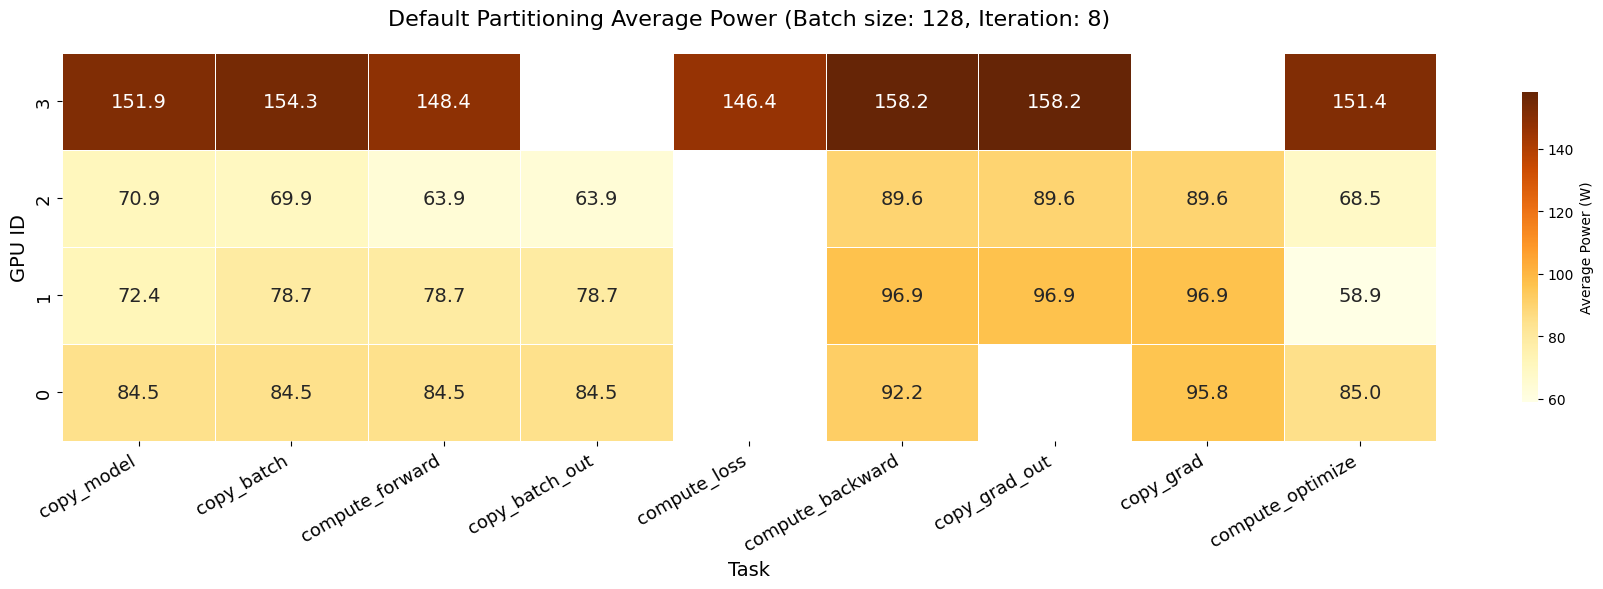

In [37]:
heatmap_data = default_df_8.pivot_table(
    index='gpu_id',
    columns='task',
    values='power',
    aggfunc='mean' # mean or max
)
ordered_columns = [col for col in kd_task_order if col in heatmap_data.columns]
heatmap_data = heatmap_data[ordered_columns]
heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='YlOrBr',
    linewidths=0.5,
    # vmax=100,
    annot_kws={"size": 14},  # 히트맵 내부 숫자 크기
    cbar_kws={'label': 'Average Power (W)', 'shrink': 0.8}
)

# x축, y축, 제목 폰트 크기 조정
plt.xticks(rotation=30, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.title(f'Default Partitioning Average Power (Batch size: {BATCH_SIZE}, Iteration: 8)', fontsize=16, pad=20)
plt.xlabel('Task', fontsize=14)
plt.ylabel('GPU ID', fontsize=14)

plt.tight_layout()
plt.show()

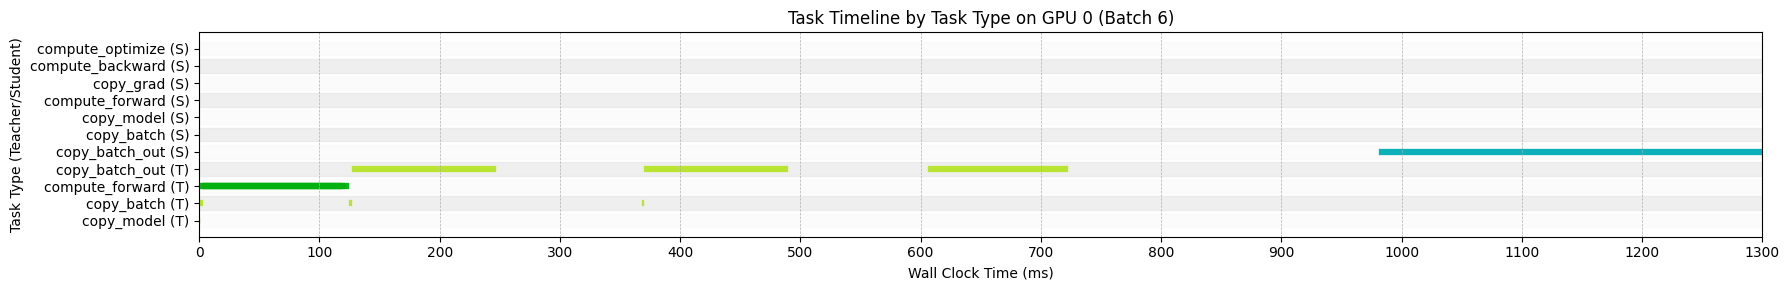

In [50]:
default_df_8_gpu0 = default_df_8[default_df_8['gpu_id'] == 0].copy()

default_df_8_gpu0['color'] = default_df_8_gpu0.apply(assign_color, axis=1)

default_df_8_gpu0['task_label'] = default_df_8_gpu0['task'] + default_df_8_gpu0['target'].apply(lambda x: ' (T)' if x else ' (S)')
task_order = default_df_8_gpu0['task_label'].drop_duplicates().tolist()
default_df_8_gpu0['y_pos'] = default_df_8_gpu0['task_label'].map({label: i for i, label in enumerate(task_order)})

# for _, row in default_df_8_gpu0.sample(10).iterrows():
#     print(row['task'], row['target'], assign_color(row))
# Plot
fig, ax = plt.subplots(figsize=(18, 3))
y_margin = 0.4

for i, task in enumerate(task_order[::-1]):
    color = '#f9f9f9' if i % 2 == 0 else '#e0e0e0'
    ax.axhspan(i - y_margin, i + y_margin, color=color, alpha=0.5, zorder=0)

for _, row in default_df_8_gpu0.iterrows():
    ax.barh(
        y=row['y_pos'],
        width=row['time'],
        left=row['start_time'],
        height=0.35,
        color=row['color'],
        edgecolor=row['color'],
        linewidth=0.2,
        alpha=0.95
    )

ax.set_yticks(range(len(task_order)))
ax.set_yticklabels(task_order)
ax.set_xlabel('Wall Clock Time (ms)')
ax.set_ylabel('Task Type (Teacher/Student)')
ax.set_title('Task Timeline by Task Type on GPU 0 (Batch 6)')  
ax.grid(axis='x', linestyle='--', linewidth=0.5)
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.set_xlim(0, 1300)


# plt.legend(
#     handles=legend_elements,
#     loc='center left',
#     bbox_to_anchor=(1.02, 0.5),
#     borderaxespad=0.0,
#     frameon=True
# )
plt.tight_layout()
plt.show()
